# Joint External Torque Visualizer
Load `.npy` files produced by `extract_torque.py` and explore the torque signals interactively.

**Workflow:**
1. Run `extract_torque.py` first to generate `<demo>_torque.npy`.
2. Fill in the path in **Cell 1 – Parameters**.
3. Run all cells.

In [68]:
# ── Cell 1 – Parameters (edit here) ─────────────────────────────────────────

# Path to the extracted .npy file
TORQUE_NPY = "/home/jiuzl/robomimic_suite/temp/demo_0_torque.npy"   # shape (T, 7)

# ── Smoothing ────────────────────────────────────────────────────────────────
SMOOTH_WINDOW  = 51    # Savitzky-Golay window length (odd integer; set to 0 to disable)
SMOOTH_POLYORD = 3     # polynomial order for Savitzky-Golay filter

# ── Plot style ───────────────────────────────────────────────────────────────
JOINTS_TO_PLOT = [0, 1, 2, 3, 4, 5, 6]   # 0-indexed; remove any you don't want
JOINT_LABELS   = [f"Joint {i+1}" for i in range(7)]

RAW_ALPHA        = 0.20   # transparency of the raw (unsmoothed) trace
RAW_LINEWIDTH    = 0.8
SMOOTH_LINEWIDTH = 3.0    # bold smoothed line

FIG_WIDTH_IN  = 19.2   # figure width  (inches) — 19.2 * 200 DPI = 3840 px
FIG_HEIGHT_IN = 10.8   # figure height (inches) — 10.8 * 200 DPI = 2160 px
DPI           = 200    # 4K

AXIS_FONTSIZE   = 40
TICK_FONTSIZE   = 40
LEGEND_FONTSIZE = 30

T_MAX = 10.0   # only plot up to this time in seconds (set to None for full duration)

SAVE_PATH = None   # set to e.g. "torque_plot.png" to save; None = display only
# ─────────────────────────────────────────────────────────────────────────────

In [69]:
# Cell 2 – Imports & helpers

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

%matplotlib inline

def smooth(signal, window, polyorder):
    """Savitzky-Golay smoothing; returns raw signal if window is 0 or too large."""
    if window == 0 or window >= len(signal):
        return signal
    w = window if window % 2 == 1 else window + 1  # must be odd
    return savgol_filter(signal, window_length=w, polyorder=polyorder)

In [70]:
# Cell 3 – Load data

torque = np.load(TORQUE_NPY)               # (T, 7)
t      = np.arange(torque.shape[0]) / 1000.0  # seconds (1 timestep = 1 ms)

print(f"Loaded: T={torque.shape[0]} steps, {torque.shape[1]} joints, duration={t[-1]:.3f}s")
print(f"Torque range: [{torque.min():.3f}, {torque.max():.3f}] Nm")

Loaded: T=13276 steps, 7 joints, duration=13.275s
Torque range: [-4.628, 6.593] Nm


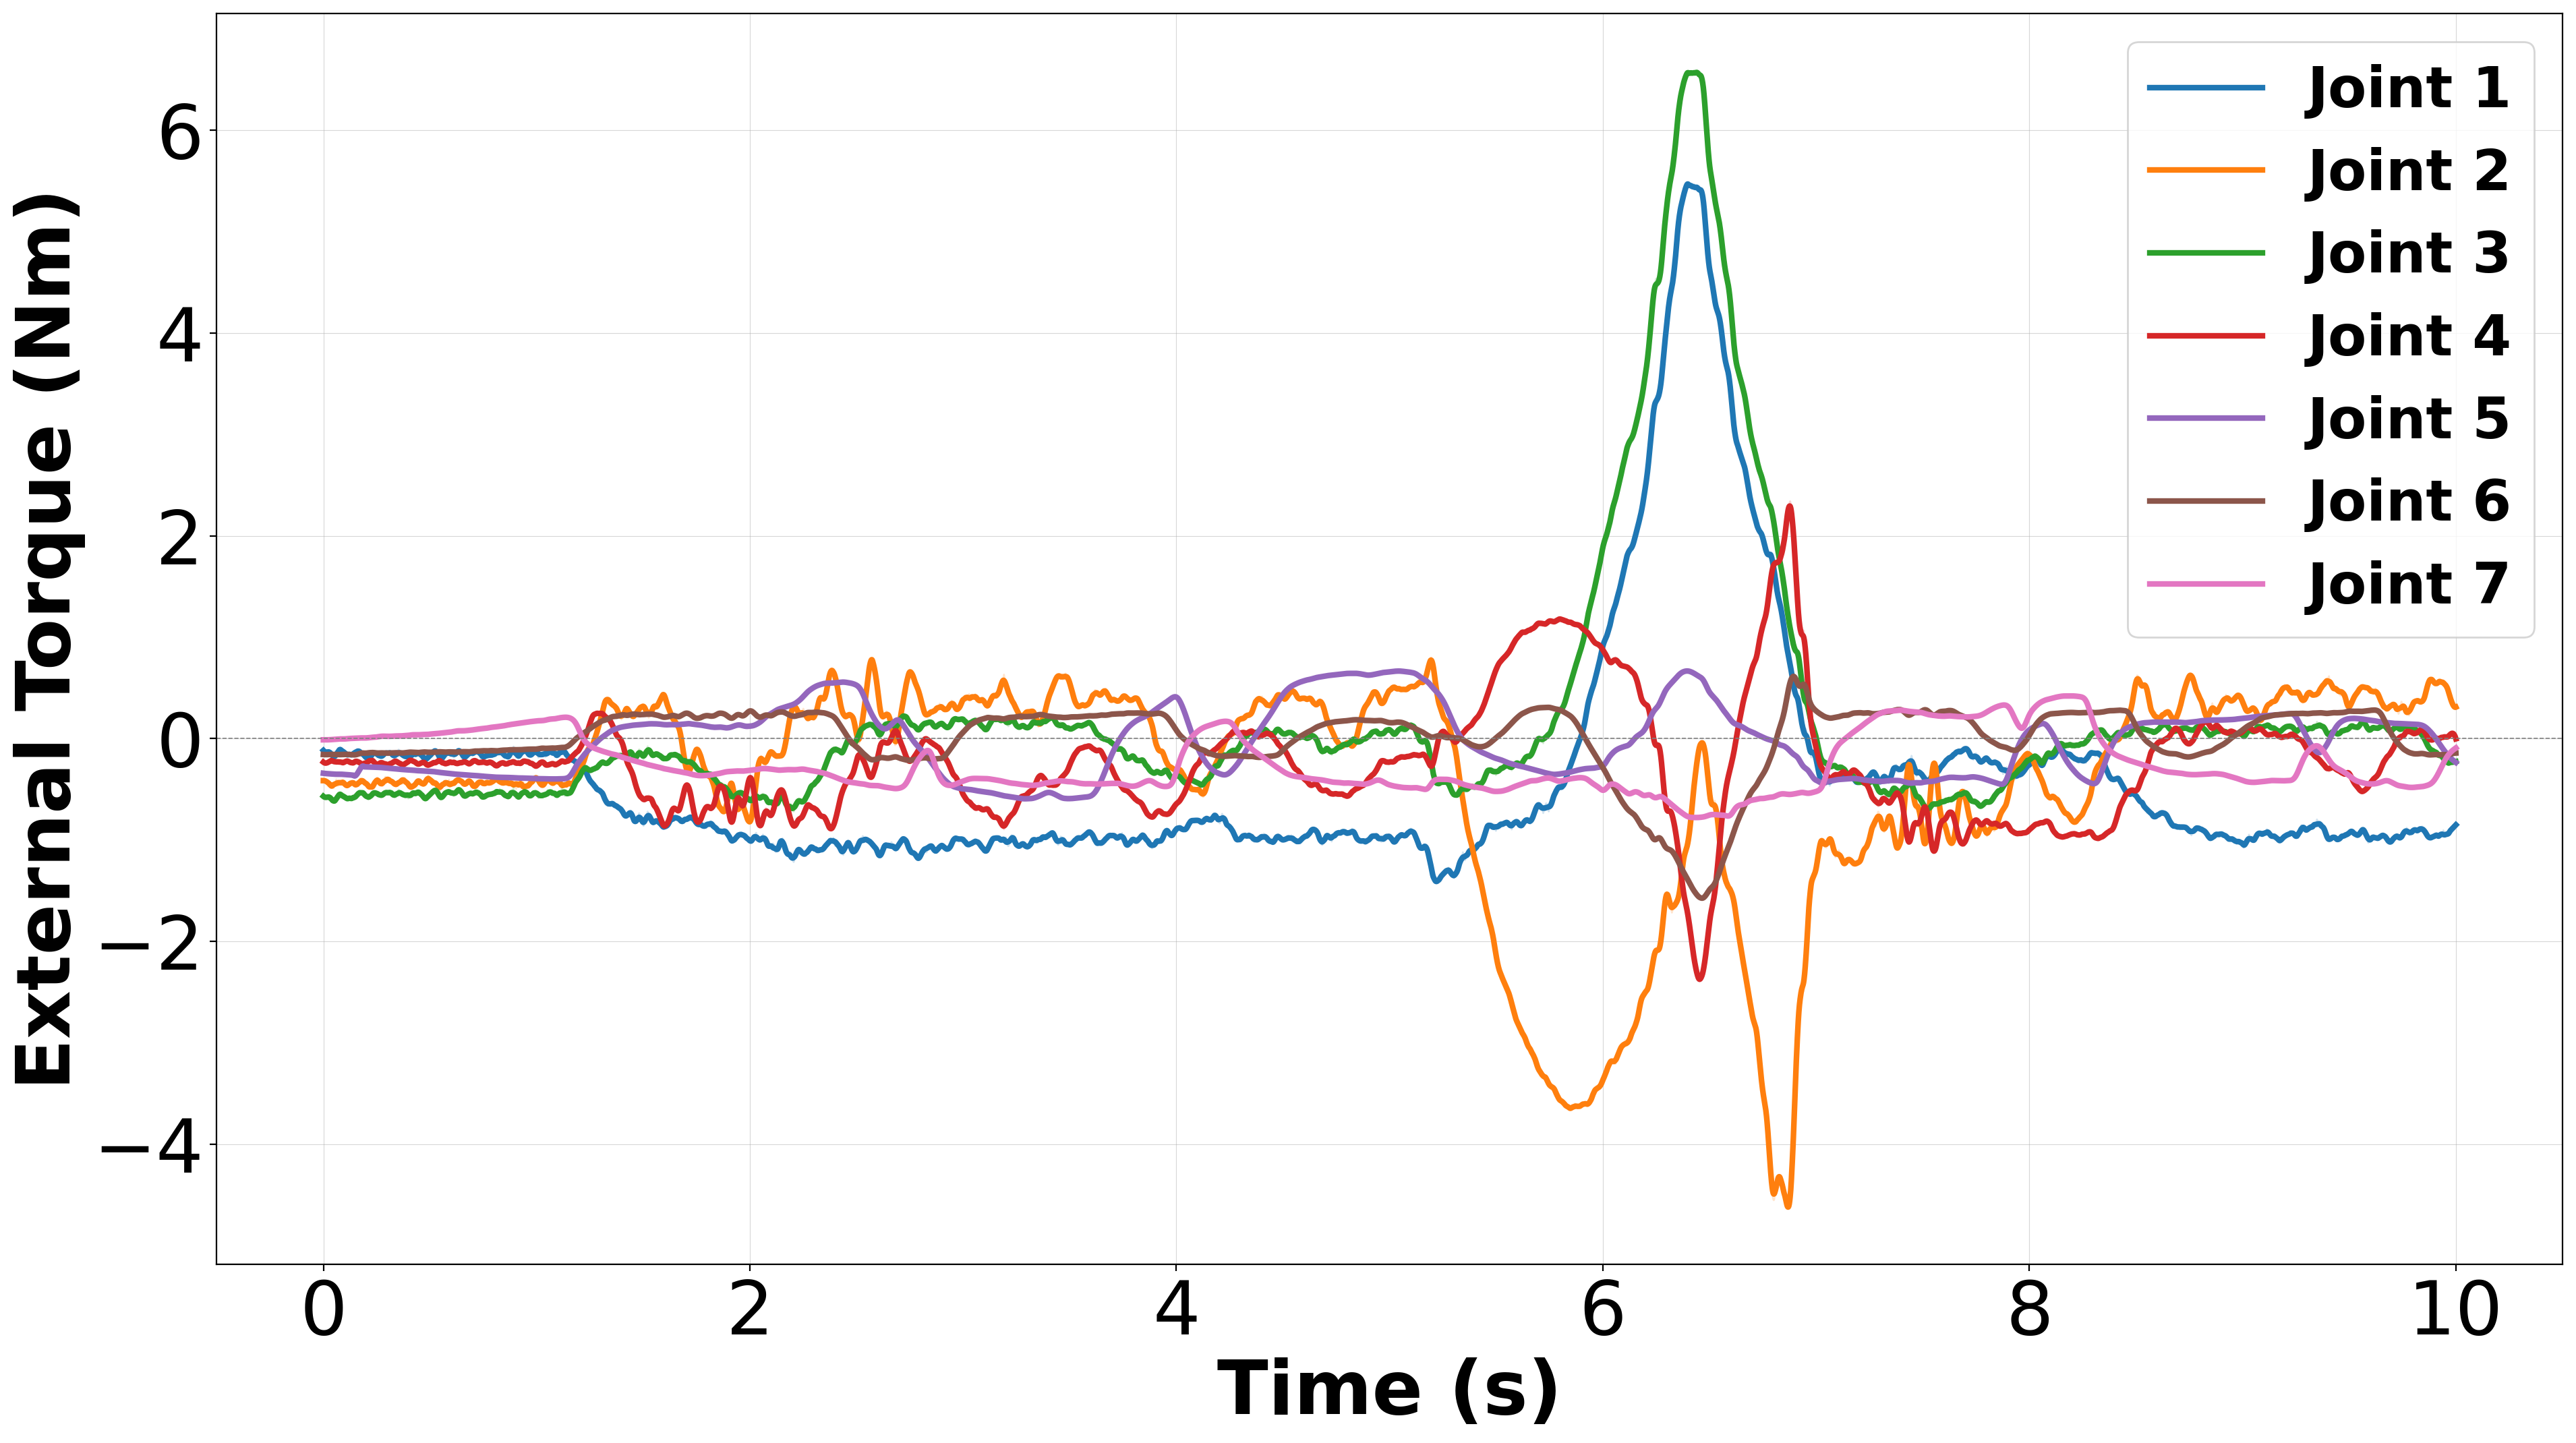

In [71]:
# Cell 4 – Main torque plot

COLORS = plt.cm.tab10.colors

mask   = (t <= T_MAX) if T_MAX is not None else slice(None)
t_plot = t[mask]

fig, ax = plt.subplots(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN), dpi=DPI)

for j in JOINTS_TO_PLOT:
    raw = torque[mask, j]
    sm  = smooth(raw, SMOOTH_WINDOW, SMOOTH_POLYORD)
    c   = COLORS[j % len(COLORS)]

    ax.plot(t_plot, raw, color=c, alpha=RAW_ALPHA, linewidth=RAW_LINEWIDTH)
    ax.plot(t_plot, sm,  color=c, linewidth=SMOOTH_LINEWIDTH, label=JOINT_LABELS[j])

ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
ax.set_xlabel("Time (s)", fontsize=AXIS_FONTSIZE, fontweight="bold")
ax.set_ylabel("External Torque (Nm)", fontsize=AXIS_FONTSIZE, fontweight="bold")
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax.legend(loc="upper right", prop={"weight": "bold", "size": LEGEND_FONTSIZE})
ax.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()

if SAVE_PATH:
    plt.savefig(SAVE_PATH, dpi=DPI)
    print(f"Saved to {SAVE_PATH}")
else:
    plt.show()

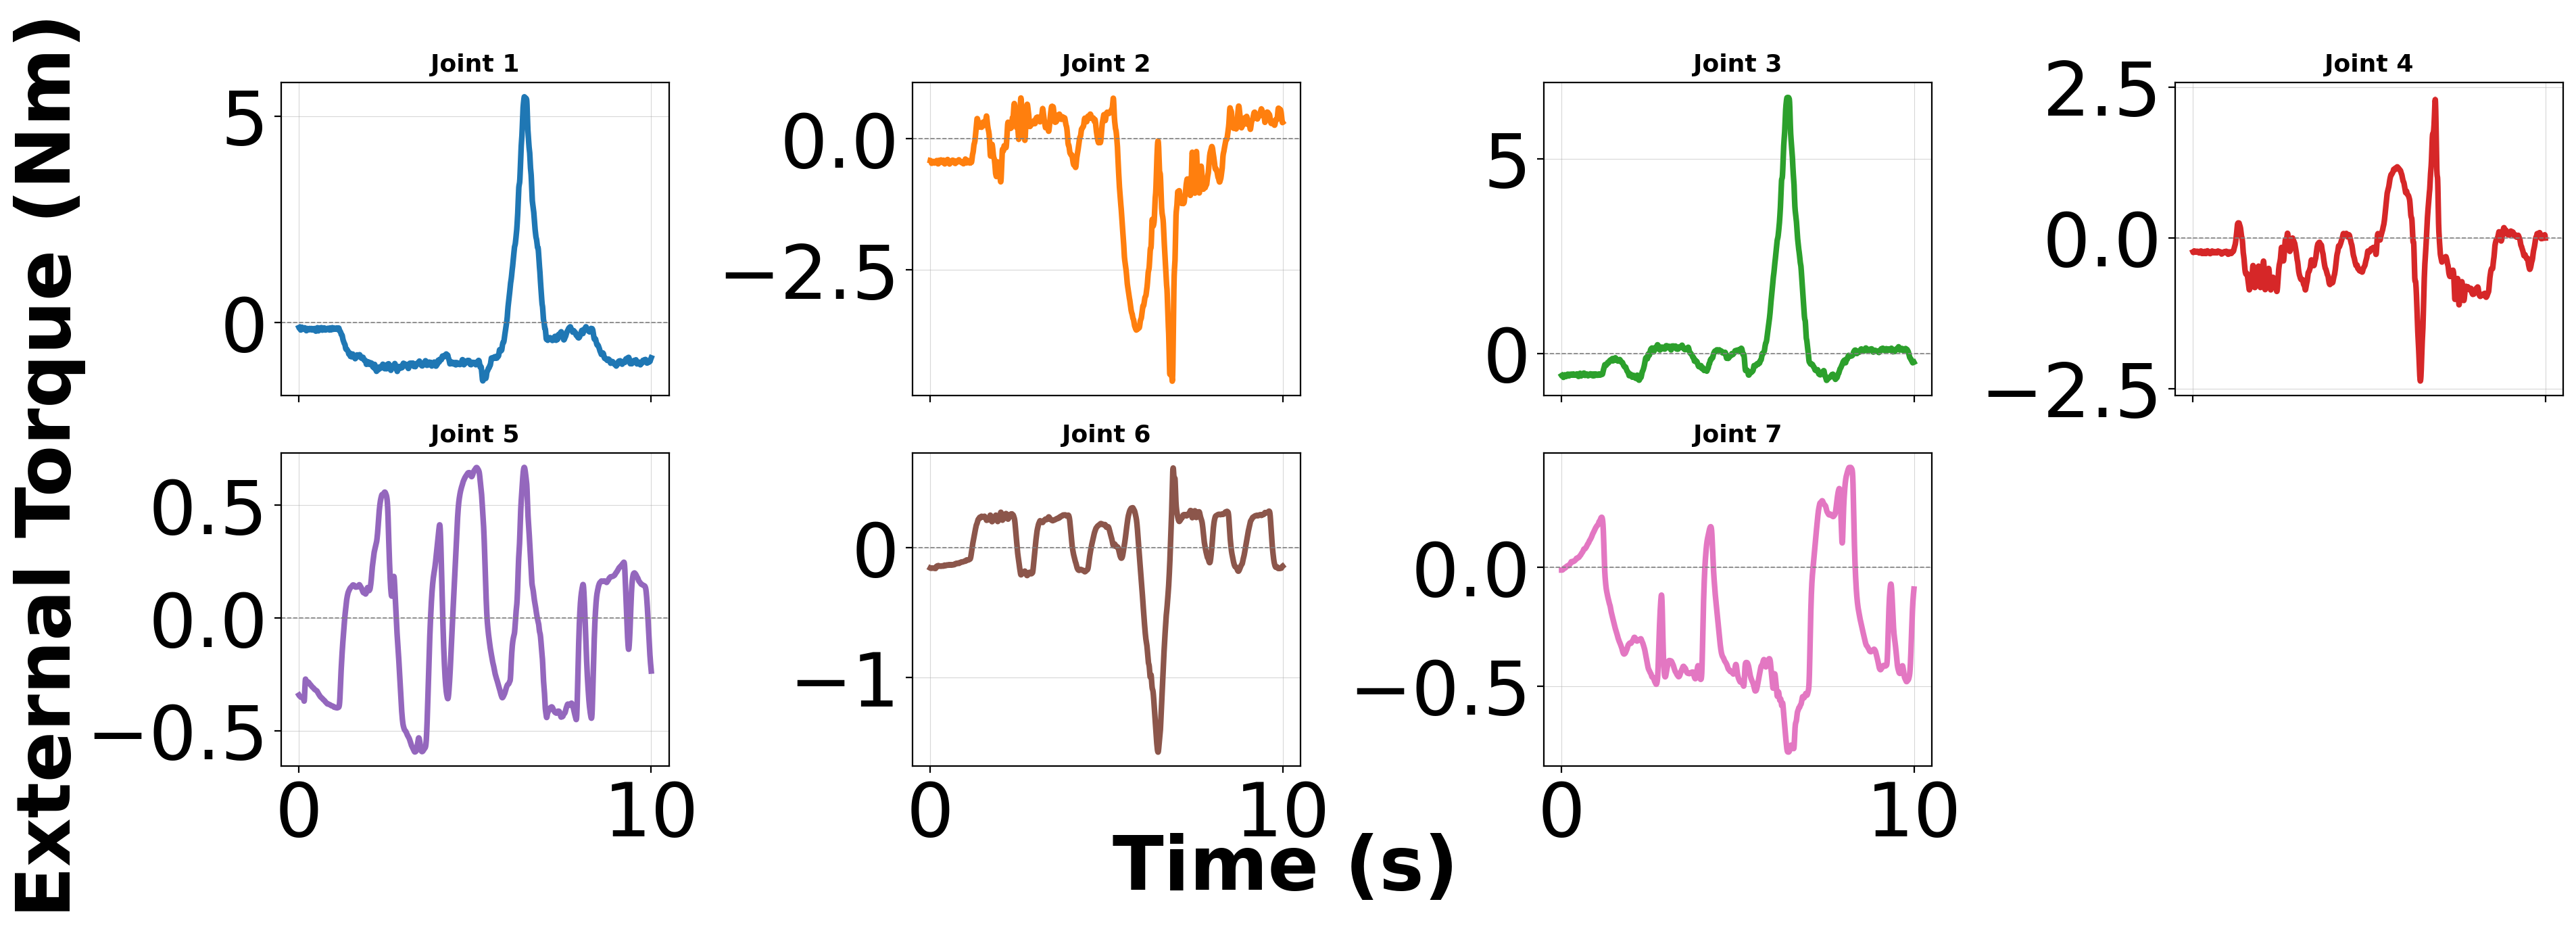

In [72]:
# Cell 5 – Per-joint subplot grid (optional, one panel per joint)

mask   = (t <= T_MAX) if T_MAX is not None else slice(None)
t_plot = t[mask]

n = len(JOINTS_TO_PLOT)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols,
                          figsize=(FIG_WIDTH_IN, nrows * 3.2), dpi=DPI,
                          sharex=True)
axes = axes.flatten()

for idx, j in enumerate(JOINTS_TO_PLOT):
    raw = torque[mask, j]
    sm  = smooth(raw, SMOOTH_WINDOW, SMOOTH_POLYORD)
    c   = COLORS[j % len(COLORS)]

    axes[idx].plot(t_plot, raw, color=c, alpha=RAW_ALPHA, linewidth=RAW_LINEWIDTH)
    axes[idx].plot(t_plot, sm,  color=c, linewidth=SMOOTH_LINEWIDTH)
    axes[idx].axhline(0, color="gray", linewidth=0.6, linestyle="--")
    axes[idx].set_title(JOINT_LABELS[j], fontsize=13, fontweight="bold")
    axes[idx].tick_params(axis="both", labelsize=TICK_FONTSIZE)
    axes[idx].grid(True, linewidth=0.4, alpha=0.5)

for ax in axes[n:]:
    ax.set_visible(False)

fig.text(0.5, 0.01, "Time (s)", ha="center", fontsize=AXIS_FONTSIZE, fontweight="bold")
fig.text(0.01, 0.5, "External Torque (Nm)", va="center",
         rotation="vertical", fontsize=AXIS_FONTSIZE, fontweight="bold")
plt.tight_layout(rect=[0.03, 0.03, 1, 1])
plt.show()

In [73]:
# Cell 6 – Quick stats table

print(f"{'Joint':<10} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10}")
print("-" * 52)
for j in JOINTS_TO_PLOT:
    col = torque[:, j]
    print(f"{JOINT_LABELS[j]:<10} {col.min():>10.3f} {col.max():>10.3f} "
          f"{col.mean():>10.3f} {col.std():>10.3f}")

Joint             Min        Max       Mean        Std
----------------------------------------------------
Joint 1        -1.424      5.474     -0.447      1.052
Joint 2        -4.628      0.803     -0.507      1.004
Joint 3        -0.721      6.593      0.072      1.154
Joint 4        -2.382      2.343     -0.228      0.517
Joint 5        -0.594      0.668     -0.046      0.318
Joint 6        -1.573      0.620      0.016      0.305
Joint 7        -0.778      0.421     -0.195      0.282
